# Phase 7: Model Optimization

## Objective

The objective of this notebook is to improve the baseline XGBoost model through hyperparameter tuning and evaluate its performance using multiple evaluation techniques.

Tasks:
- Hyperparameter tuning
- Cross Validation
- Final evaluation
- Feature Importance
- Save optimized model

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report,
    f1_score
)

from xgboost import XGBClassifier

In [5]:
import joblib

data = joblib.load("../models/train_test_split.pkl")

X_train = data["X_train"]
X_test = data["X_test"]

y_train = data["y_train"]
y_test = data["y_test"]

In [3]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [6]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [7]:
X_train_processed
X_test_processed

y_train
y_test

803     0
3549    0
3515    0
5162    0
4642    0
       ..
5660    0
5150    0
4708    0
5381    0
6000    0
Name: Churn Label, Length: 1409, dtype: int64

In [8]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [9]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,1],

    "colsample_bytree":[0.8,1]

}

In [10]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=42,

    n_jobs=-1

)

In [11]:
random_search.fit(
    X_train_processed,
    y_train
)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 100,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [13]:
random_search.best_score_

np.float64(0.9343763886383216)

In [14]:
best_model = random_search.best_estimator_

In [15]:
y_pred = best_model.predict(X_test_processed)

y_prob = best_model.predict_proba(
    X_test_processed
)[:,1]

In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1035
           1       0.96      0.90      0.93       374

    accuracy                           0.97      1409
   macro avg       0.96      0.95      0.95      1409
weighted avg       0.97      0.97      0.96      1409



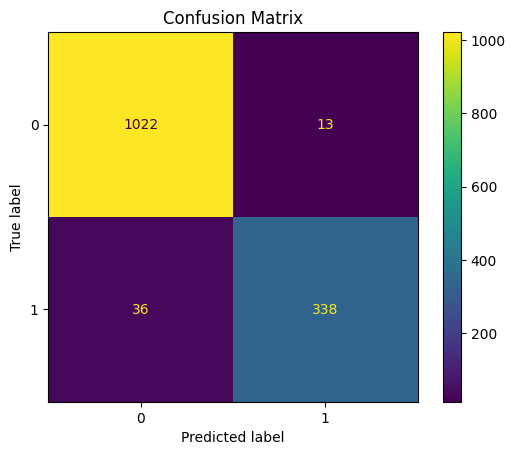

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.title(
    "Confusion Matrix"
)

plt.show()

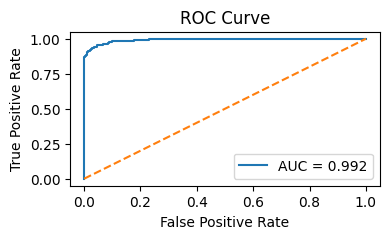

In [19]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(4,2))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

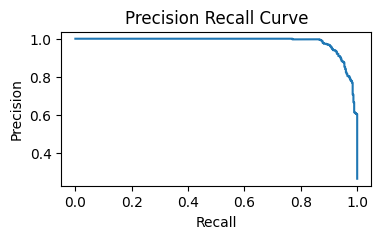

In [20]:
precision,recall,_ = precision_recall_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(4,2))

plt.plot(

    recall,

    precision

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [22]:
scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train,
    scoring="f1",
    cv=cv
)

In [23]:
print(scores)
print(scores.mean())

[0.94276094 0.93150685 0.93039049 0.92929293 0.93565217]
0.933920677528383


In [25]:
feature_names = preprocessor.get_feature_names_out()
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":best_model.feature_importances_

})
importance = importance.sort_values(

    by="Importance",

    ascending=False

)

In [26]:
importance.head(20)

,Feature,Importance
16,num__Satisfaction Score,0.342985
1165,cat__Contract_Month-to-Month,0.121215
21,cat__Senior Citizen_No,0.088346
1149,cat__Online Security_No,0.047577
1150,cat__Online Security_Yes,0.039016
22,cat__Senior Citizen_Yes,0.028689
1147,cat__Internet Type_Fiber Optic,0.017438
6,num__Number of Referrals,0.016502
1171,cat__Payment Method_Credit Card,0.014987
25,cat__Dependents_No,0.014193


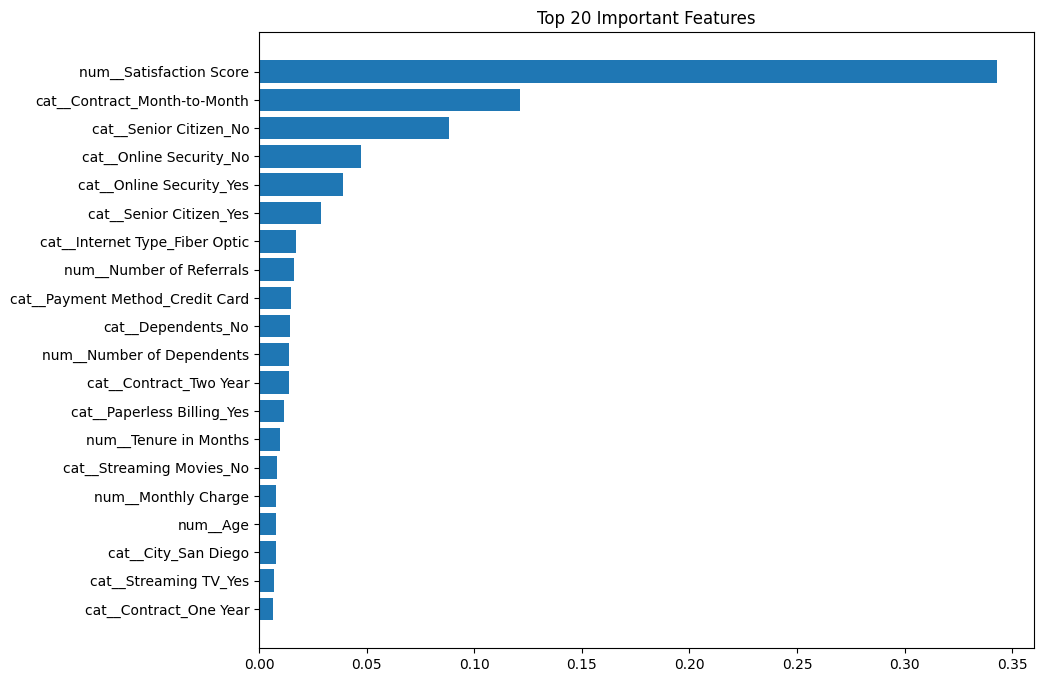

In [29]:
top20 = importance.head(20)
plt.figure(figsize=(10,8))
plt.barh(
    top20["Feature"],
    top20["Importance"]
)
plt.gca().invert_yaxis()
plt.title(
    "Top 20 Important Features"
)
plt.show()

In [30]:
joblib.dump(
    best_model,
    "../models/final_xgboost_model.pkl"
)

['../models/final_xgboost_model.pkl']

# Summary

In this notebook we:

- Tuned the XGBoost model using RandomizedSearchCV.
- Selected the best hyperparameters.
- Evaluated the optimized model.
- Performed Cross Validation.
- Visualized the Confusion Matrix.
- Generated ROC and Precision-Recall curves.
- Identified the most important features.
- Saved the optimized model.